In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader


In [3]:
# Configuration
train_dir = 'train_images_ecg'
test_dir = 'test_images_ecg'
batch_size = 32
num_epochs = 5
num_classes = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
# Image transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # For grayscale images
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
# Define CNN model
class ECGCNN(nn.Module):
    def __init__(self, num_classes):
        super(ECGCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 1 channel for grayscale
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc_block = nn.Sequential(
            nn.Linear(64 * 32 * 32, 256),  # Assuming 128x128 input
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [9]:
# For graphs
train_losses = []
train_accuracies = []

In [11]:
# Instantiate model, loss, and optimizer
model = ECGCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {running_loss:} | Train Accuracy: {correct}/{total}")



Epoch 1/5 | Loss: 375.7420390044572 | Train Accuracy: 84341/87554
Epoch 2/5 | Loss: 214.15122707292903 | Train Accuracy: 85674/87554
Epoch 3/5 | Loss: 157.589424240854 | Train Accuracy: 86082/87554
Epoch 4/5 | Loss: 122.56193996391085 | Train Accuracy: 86376/87554
Epoch 5/5 | Loss: 95.90466025827118 | Train Accuracy: 86611/87554


In [13]:
# Evaluation loop
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
print(f"{(correct / total) * 100}")


98.23953823953823


In [28]:
all_labels = []
all_preds = []

for images, labels in test_loader:  # assuming you're using a DataLoader
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    all_labels.extend(labels.cpu().numpy())
    all_preds.extend(predicted.cpu().numpy())


In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

# Convert to numpy arrays just in case
y_true = np.array(all_labels)
y_pred = np.array(all_preds)

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy: {accuracy * 100}%")

# Precision, Recall, F1 for each class
precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

# Print for each class
print("\nPer-Class Metrics (Class 0 to 4):")
for i in range(num_classes):
    print(f"Class {i}:")
    print(f"  Precision: {precision[i]:}")
    print(f"  Recall:    {recall[i]:}")
    print(f"  F1-Score:  {f1[i]:}")




Overall Accuracy: 98.23953823953823%

Per-Class Metrics (Class 0 to 4):
Class 0:
  Precision: 0.9867643841610151
  Recall:    0.9958052765205873
  F1-Score:  0.9912642162518543
Class 1:
  Precision: 0.9084821428571429
  Recall:    0.7320143884892086
  F1-Score:  0.8107569721115537
Class 2:
  Precision: 0.9694167852062588
  Recall:    0.9412983425414365
  F1-Score:  0.9551506657323056
Class 3:
  Precision: 0.8592592592592593
  Recall:    0.7160493827160493
  F1-Score:  0.7811447811447811
Class 4:
  Precision: 0.9593810444874274
  Recall:    0.9802371541501976
  F1-Score:  0.9696969696969697



Confusion Matrix:
[[18042    40    23     2    11]
 [  138   407     9     0     2]
 [   60     1  1363    17     7]
 [   36     0     9   116     1]
 [    8     0     2     0   496]]


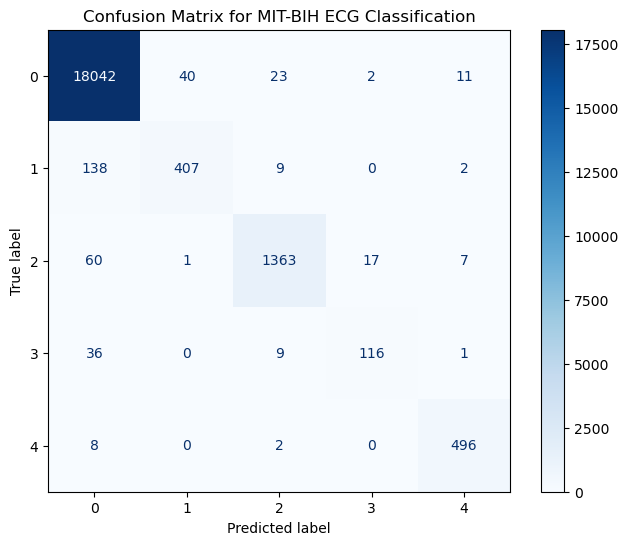

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:")
print(cm)
# Visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3, 4])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix for MIT-BIH ECG Classification")
plt.show()
